## Similarity Construction and Visualization

To demonstrate how we construct biologically informed similarity constraints, we use the **MERFISH mouse spinal cord dataset**, which contains curated cell-type annotations suitable for quantitative evaluation.

For clearer visualization and block structure, we restrict this demonstration to **neuronal cell types only**.

We define similarity in three stages:

1. **Leiden–Marker Similarity**  
   Similarity computed from marker genes extracted via unsupervised Leiden clustering followed by Wilcoxon differential expression.
2. **Spatial Neighbor–Aggregated Similarity**  
   Similarity computed after smoothing expression using spatial k-nearest neighbors.
3. **Fused Similarity (Hadamard × K-means Thresholding)**  
   Intersection of (1) and (2), used as positive and negative supervision for contrastive learning.

This procedure produces high-confidence structural supervision before model training.

In [ ]:
import os
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Data Path
h5ad_path       = "/PATH/TO/MERFISH_spinal_cord_resolved_0505.h5ad"
section_ids     = ["0503_F5_T"]
annotation_col  = "MERFISH cell type annotation"

# For Leiden-marker similarity
n_markers            = 3
neighbor_lambda_expr = 0.5 

# For spatial neighbor similarity
n_neighbors_spatial  = 6 
neighbor_lambda_spat = 0.2

### Step 1 — Leiden–Marker Similarity

We first perform Leiden clustering and extract cluster-enriched marker genes via Wilcoxon rank-sum testing. Cosine similarity is computed using only these genes.

**What this captures:**

- separation of transcriptionally distinct cell types  
- cell-identity structure independent of spatial context  
- strong block structure aligned to biological programs

This forms a biologically grounded baseline similarity matrix.

In [ ]:
def load_merfish_spinal(h5ad_path, section_ids):
    ad = sc.read_h5ad(h5ad_path)
    return ad[ad.obs['Section ID'].isin(section_ids)].copy()


def run_unsup_marker(adata, scenario_name, annotation_col, n_markers=20, neighbor_lambda=0.5):
    """
    Given an AnnData subset, run PCA→graph(neighbors)→Leiden→rank_genes_groups,
    then compute cosine similarity on aggregated features (self + λ * neighbor features).
    """
    if adata.n_obs < 2:
        print(f"[{scenario_name}] SKIPPED: only {adata.n_obs} cells")
        return None

    print(f"[{scenario_name}] {adata.n_obs} cells → running leiden-marker pipeline")
    adata.X = adata.X.astype('float32')

    # PCA & build neighbor graph (6 neighbors)
    n_comps = min(50, adata.n_obs - 1)
    sc.pp.pca(adata, n_comps=n_comps)
    sc.pp.neighbors(adata, n_neighbors=6, n_pcs=n_comps)

    # Leiden clustering
    sc.tl.leiden(adata, resolution=1.2, key_added="leiden_clusters")

    # top markers per Leiden cluster
    sc.tl.rank_genes_groups(
        adata,
        groupby="leiden_clusters",
        method="wilcoxon",
        n_genes=n_markers
    )
    clusters = adata.obs["leiden_clusters"].cat.categories.tolist()
    all_markers = []
    for cl in clusters:
        df_cl = sc.get.rank_genes_groups_df(adata, group=cl)
        all_markers.extend(df_cl['names'].tolist())
    all_markers = sorted(set(all_markers))
    print(f"  → {len(all_markers)} unique markers across {len(clusters)} clusters")

    # build augmented feature matrix (expression graph)
    feat = adata[:, all_markers].X.toarray()     
    conn = adata.obsp['connectivities']            
    neigh_feat = conn.dot(feat)                   
    feat_aug = feat + neighbor_lambda * neigh_feat 

    # cosine similarity on augmented features
    sim = cosine_similarity(feat_aug)
    sim = (sim - sim.min()) / (sim.max() - sim.min())

    # sort by GT
    gt    = adata.obs[annotation_col].astype(str).values
    order = np.argsort(gt)
    sim_plot = sim[order][:, order]

    # block boundaries for visualization
    unique_gt, starts = np.unique(gt[order], return_index=True)
    starts = list(starts) + [len(order)]
    tick_pos = [(starts[i] + starts[i+1] - 1) / 2 for i in range(len(unique_gt))]
    tick_lab = list(unique_gt)

    # raw sim heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        sim_plot, cmap="viridis",
        cbar_kws={"label": "Cosine Similarity"},
        xticklabels=False, yticklabels=False, square=True
    )
    for b in starts[1:-1]:
        plt.axhline(b, color="white", linestyle="--", linewidth=1.2)
        plt.axvline(b, color="white", linestyle="--", linewidth=1.2)
    plt.xticks(tick_pos, tick_lab, rotation=90, fontsize=8)
    plt.yticks(tick_pos, tick_lab, fontsize=8)
    plt.title(f"{scenario_name} (#cells = {adata.n_obs})")
    plt.tight_layout()
    plt.show()

    # distribution of off-diagonal sim values
    iu = np.triu_indices_from(sim_plot, k=1)
    vals = sim_plot[iu]
    plt.figure(figsize=(6, 4))
    sns.histplot(vals, bins=50, kde=True)
    plt.xlabel("Cosine similarity")
    plt.ylabel("Count")
    plt.title(f"{scenario_name} — sim value distribution")
    plt.tight_layout()
    plt.show()

    return sim_plot



Loading & subsetting H5AD…
Total: 1927 cells × 500 genes
adata.obs columns: ['Datasets', 'volume', 'center_x', 'center_y', '1st round cluster', '2nd round subcluster', 'MERFISH cell type annotation', 'Region', 'Excitatory_vs_Inhibitory', 'Markers', 'Note', 'Neurotransmitter', 'Laminae', 'Gender', 'Mouse ID', 'Axial level', 'Section ID']
Non-neuronal subset: 1255 cells
[chunk_nonNeuron_only] 1255 cells → running leiden-marker pipeline
  → 34 unique markers across 19 clusters


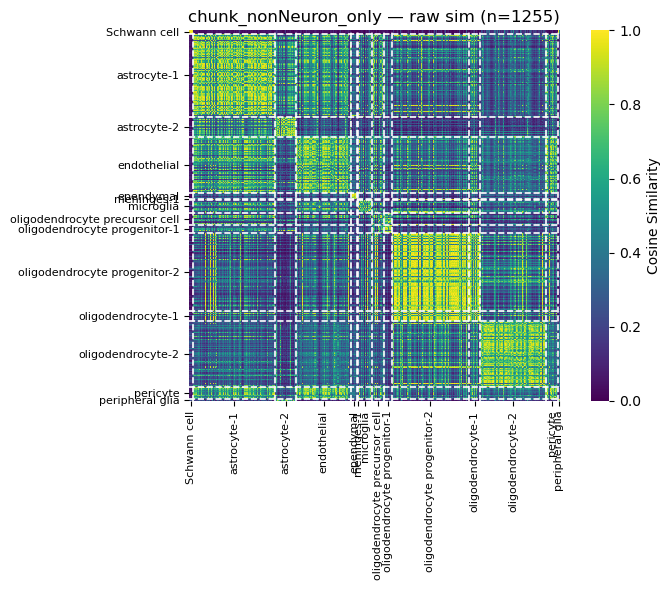

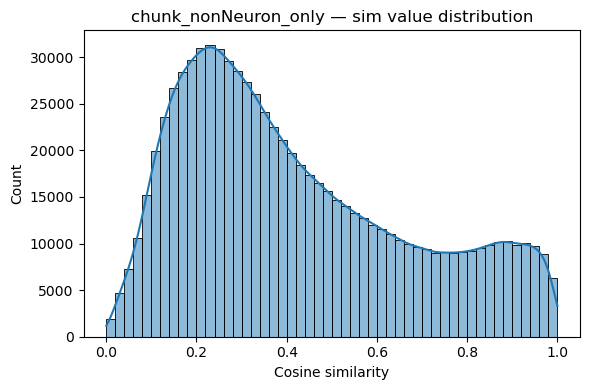

In [ ]:
print("Loading & subsetting H5AD…")
adata = load_merfish_spinal(h5ad_path, section_ids)
print(f"Total: {adata.n_obs} cells × {adata.n_vars} genes")
print("adata.obs columns:", adata.obs.columns.tolist())

if annotation_col not in adata.obs.columns:
    raise KeyError(f"Column '{annotation_col}' not found in adata.obs")

# Non-neuronal subset
anno            = adata.obs[annotation_col].astype(str)
has_two_dashes  = anno.str.count('-') == 2
contains_neuron = anno.str.contains('neuron', case=False)
non_neuron_mask = ~(has_two_dashes | contains_neuron)

adata_non_neuron = adata[non_neuron_mask].copy()
print(f"Non-neuronal subset: {adata_non_neuron.n_obs} cells")

# Leiden Marker pipeline + visualization
sim_plot_markers = run_unsup_marker(
    adata_non_neuron,
    scenario_name="Leiden-Marker Similarity",
    annotation_col=annotation_col,
    n_markers=n_markers,
    neighbor_lambda=neighbor_lambda_expr,
)

### Step 2 — Spatial Neighbor–Aggregated Similarity

Spatial transcriptomics signals are sparse. To stabilize noisy expression, we aggregate expression across spatial neighborhoods using the k-nearest-neighbor graph:

`Aggregated = X_self + λ ⋅ mean(X_neighbors)`

This emphasizes anatomical proximity while reducing dropout-based sparsity.

**What this captures:**

- laminar and compartment-level organization
- microenvironment-driven gradients
- stable similarity across spatial neighborhoods

This similarity reflects tissue geometry rather than intrinsic identity.


Spatial graph shape: (1255, 1255)
Augmented spatial feature matrix: (1255, 200)


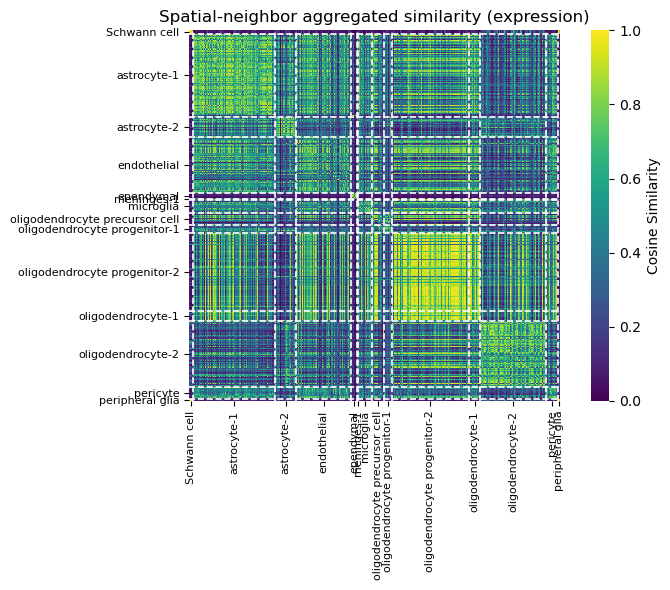

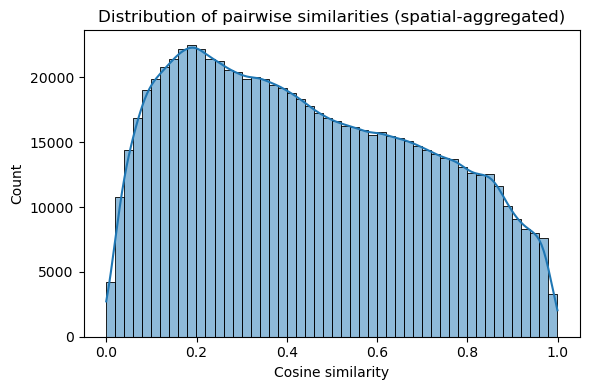

In [ ]:
# Require spatial coordinates for spatial-neighbor similarity
if "spatial" not in adata_non_neuron.obsm:
    raise KeyError("adata_non_neuron.obsm['spatial'] is missing; spatial coordinates are required.")

# Preprocessing
sc.pp.highly_variable_genes(adata_non_neuron, n_top_genes=200, flavor='seurat_v3')
adata_spat = adata_non_neuron[:, adata_non_neuron.var["highly_variable"]].copy()
adata_spat.X = adata_spat.X.astype('float32')
# Use spatial coordinates
adata_spat.obsm["X_spatial"] = adata_spat.obsm["spatial"].astype("float32")

# Build spatial neighbors graph
sc.pp.neighbors(
    adata_spat,
    n_neighbors=n_neighbors_spatial,
    use_rep="X_spatial",
    metric="euclidean"
)
conn_spatial = adata_spat.obsp["connectivities"]
print("Spatial graph shape:", conn_spatial.shape)

# Augmented features: self + λ * spatial neighbors
feat_spat       = adata_spat.X.toarray()            
neigh_feat_spat = conn_spatial.dot(feat_spat)      
feat_aug_spat   = feat_spat + neighbor_lambda_spat * neigh_feat_spat

print("Augmented spatial feature matrix:", feat_aug_spat.shape)

# Cosine similarity + min-max normalization
sim_spat = cosine_similarity(feat_aug_spat)
sim_spat = (sim_spat - sim_spat.min()) / (sim_spat.max() - sim_spat.min() + 1e-8)

# Sort by GT (same logic as second script)
gt_spat = adata_spat.obs[annotation_col].astype(str).values
order_spat = np.argsort(gt_spat)
sim_plot_spat = sim_spat[order_spat][:, order_spat]

unique_gt_spat, starts_spat = np.unique(gt_spat[order_spat], return_index=True)
starts_spat = list(starts_spat) + [len(order_spat)]
tick_pos_spat = [(starts_spat[i] + starts_spat[i+1] - 1) / 2 for i in range(len(unique_gt_spat))]

# Raw spatial similarity heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    sim_plot_spat,
    cmap="viridis",
    cbar_kws={"label": "Cosine Similarity"},
    xticklabels=False,
    yticklabels=False,
    square=True,
)
for b in starts_spat[1:-1]:
    plt.axvline(b, color="white", linestyle="--", lw=1.2)
    plt.axhline(b, color="white", linestyle="--", lw=1.2)

plt.xticks(tick_pos_spat, unique_gt_spat, rotation=90, fontsize=8)
plt.yticks(tick_pos_spat, unique_gt_spat, fontsize=8)
plt.title("Spatial-neighbor aggregated similarity")
plt.tight_layout()
plt.show()

# Distribution of spatial similarities
iu_spat   = np.triu_indices_from(sim_plot_spat, k=1)
vals_spat = sim_plot_spat[iu_spat]

plt.figure(figsize=(6, 4))
sns.histplot(vals_spat, bins=50, kde=True)
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.title("Spatial-neighbor — sim value distribution")
plt.tight_layout()
plt.show()

### Step 3 — Fused Similarity with K-Means Thresholding

To obtain high-confidence relational supervision, we combine biological and spatial similarity via element-wise multiplication:

`S_fused = S_marker ⊙ S_spatial`

We then apply **two-centroid K-means** to split the fused similarity distribution into:

- **High-similarity pairs (positives)** → pulled together via InfoNCE  
- **Low-similarity pairs (negatives)** → pushed apart in latent space  

Intermediate values are ignored to avoid ambiguous supervision.

### Comparison of Signal Sources

| Similarity Type | Signal | Strengths | Limitations |
|----------------|--------|-----------|-------------|
| Leiden–Marker | Cell identity | Strong biological specificity | No spatial context |
| Spatial Aggregated | Tissue geometry | Captures laminar structure, denoises signals | May blur distinct identities |
| Fused | Identity ∩ Spatial geometry | High-confidence constraints | Requires thresholding |

The fused similarity uses intersection rather than union, enforcing only reliable cell–cell relationships.

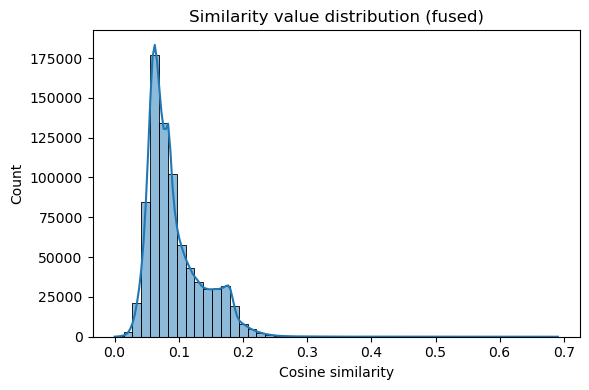

KMeans centroids: low=0.1000, high=0.1566


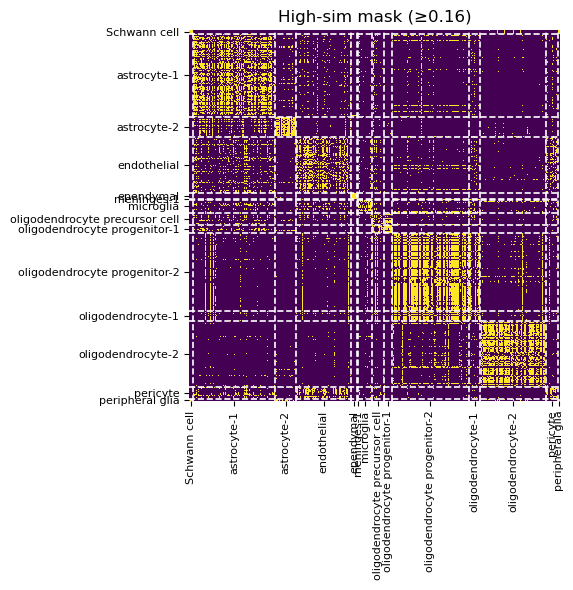

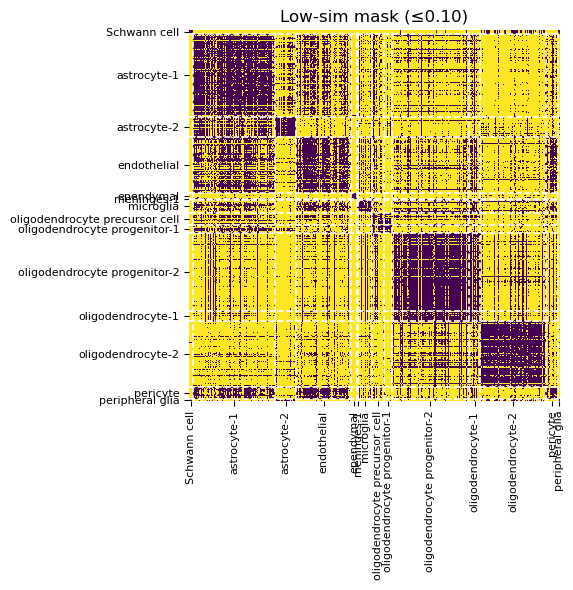

In [ ]:
from sklearn.cluster import KMeans

# Final fused similarity
sim_mul = sim_plot_markers * sim_plot_spat

# z-score normalize per row
row_mean = sim_mul.mean(axis=1, keepdims=True)
row_std  = sim_mul.std(axis=1, keepdims=True) + 1e-8
sim_mul_z = (sim_mul - row_mean) / row_std

# rescale to [0,1] for visualization
sim_plot_new = (sim_mul_z - sim_mul_z.min()) / (sim_mul_z.max() - sim_mul_z.min())

unique_gt = unique_gt_spat
starts    = starts_spat
tick_pos  = tick_pos_spat

# Distribution of off-diagonal similarities
iu_new = np.triu_indices_from(sim_plot_new, k=1)
vals_new = sim_plot_new[iu_new]

plt.figure(figsize=(6, 4))
sns.histplot(vals_new, bins=50, kde=True)
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.title("Similarity value distribution (fused)")
plt.tight_layout()
plt.show()

# K-Means thresholding for high/low similarity
vals_new_reshape = vals_new.reshape(-1, 1)
kmeans = KMeans(n_clusters=2, random_state=0, n_init=50)
kmeans.fit(vals_new_reshape)
centroids = np.sort(kmeans.cluster_centers_.flatten())
low_centroid, high_centroid = centroids
# just for sanity
low_centroid = max(0.1, low_centroid)
high_centroid = max(0.1, high_centroid)
low_centroid = min(0.9, low_centroid)
high_centroid = min(0.9, high_centroid)
print(f"KMeans centroids: low={low_centroid:.4f}, high={high_centroid:.4f}")

# High-threshold binary mask (above or equal to high centroid)
sim_high = (sim_plot_new >= high_centroid).astype(int)
plt.figure(figsize=(8, 6))
sns.heatmap(
    sim_high,
    cmap="viridis",
    cbar=False,
    xticklabels=False,
    yticklabels=False,
    square=True
)
for b in starts[1:-1]:
    plt.axhline(b, color="white", linestyle="--", lw=1.2)
    plt.axvline(b, color="white", linestyle="--", lw=1.2)
plt.xticks(tick_pos, unique_gt, rotation=90, fontsize=8)
plt.yticks(tick_pos, unique_gt, fontsize=8)
plt.title(f"High-sim mask (≥{high_centroid:.2f})")
plt.tight_layout()
plt.show()

# Low-threshold binary mask (below or equal to low centroid)
sim_low = (sim_plot_new <= low_centroid).astype(int)
plt.figure(figsize=(8, 6))
sns.heatmap(
    sim_low,
    cmap="viridis",
    cbar=False,
    xticklabels=False,
    yticklabels=False,
    square=True
)
for b in starts[1:-1]:
    plt.axhline(b, color="white", linestyle="--", lw=1.2)
    plt.axvline(b, color="white", linestyle="--", lw=1.2)
plt.xticks(tick_pos, unique_gt, rotation=90, fontsize=8)
plt.yticks(tick_pos, unique_gt, fontsize=8)
plt.title(f"Low-sim mask (≤{low_centroid:.2f})")
plt.tight_layout()
plt.show()

### Conclusion

This multi-stage similarity pipeline provides structured supervision for representation learning:

- **Biological priors** shape identity-aligned latent axes  
- **Spatial aggregation** preserves anatomical organization  
- **K-means thresholding** selects confident pairs for supervision

The resulting fused similarity matrix underlies BioLACE’s contrastive loss, producing embeddings that are:

- spatially coherent  
- biologically interpretable  
- robust to noise and dropout

This similarity construction is central to generating meaningful latent structure in spatial transcriptomics.